In [1]:
import tensorflow as tf
import pandas as pd
import seaborn as sns


In [2]:
Dataset_dir = "C:\MAJOR\Dataset\TB_Chest_Radiography_Database"


In [10]:
BATCH_SIZE       = 32
IMG_HEIGHT_WIDTH = 256
IMG_INPUT_SHAPE  = (IMG_HEIGHT_WIDTH, IMG_HEIGHT_WIDTH, 3)
MAX_EPOCHS       = 50

In [11]:
DS_TRAIN = tf.keras.utils.image_dataset_from_directory(
    Dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT_WIDTH, IMG_HEIGHT_WIDTH),
    batch_size=BATCH_SIZE
)
DS_VALID = tf.keras.utils.image_dataset_from_directory(
    Dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT_WIDTH, IMG_HEIGHT_WIDTH),
    batch_size=BATCH_SIZE
)

Found 3695 files belonging to 2 classes.
Using 2956 files for training.
Found 3695 files belonging to 2 classes.
Using 739 files for validation.


In [12]:
AUTOTUNE = tf.data.AUTOTUNE
DS_TRAIN = DS_TRAIN.cache().prefetch(buffer_size=AUTOTUNE)
DS_VALID = DS_VALID.cache().prefetch(buffer_size=AUTOTUNE)


In [13]:
import tensorflow as tf

def get_model(tf_model="ResNet50"):
    base_model = tf.keras.applications.ResNet50(
        include_top=False, weights="imagenet", input_tensor=tf.keras.Input(shape=IMG_INPUT_SHAPE)
    )
    base_model.trainable = False  # Freeze ResNet50 layers

    model = tf.keras.models.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),  # Replaces Flatten
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(2, activation='softmax')
    ])
    
    return model


In [14]:
BASIC_MODEL = tf.keras.models.Sequential()
BASIC_MODEL.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
BASIC_MODEL.add(tf.keras.layers.MaxPooling2D((2, 2)))
BASIC_MODEL.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu'))
BASIC_MODEL.add(tf.keras.layers.MaxPooling2D((2, 2)))
BASIC_MODEL.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu'))
BASIC_MODEL.add(tf.keras.layers.Flatten())
BASIC_MODEL.add(tf.keras.layers.Dense(256, activation='relu'))
BASIC_MODEL.add(tf.keras.layers.Dense(64, activation='relu'))
BASIC_MODEL.add(tf.keras.layers.Dense(2, activation='softmax'))

In [15]:
RESNET50_MODEL= get_model("ResNet50")


In [16]:
RESNET50_MODEL.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 8, 8, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,784,706 (94.55 MB)

 Trainable params: 1,196,994 (4.57 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [17]:
def compile_and_fit(model):
    model.compile(optimizer='adam',
      loss=tf.losses.SparseCategoricalCrossentropy(),
      metrics=['accuracy'])
    history = model.fit(
      DS_TRAIN,
      validation_data=DS_VALID,
      epochs=MAX_EPOCHS
    )
    return history

In [18]:
RESNET50_HISTORY = compile_and_fit(RESNET50_MODEL)


Epoch 1/50


C:\Users\saite\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_274']
Received: inputs=Tensor(shape=(None, 256, 256, 3))
  warnings.warn(msg)


93/93 ━━━━━━━━━━━━━━━━━━━━ 298s 3s/step - accuracy: 0.9054 - loss: 0.2246 - val_accuracy: 0.9824 - val_loss: 0.0423
Epoch 2/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 295s 3s/step - accuracy: 0.9851 - loss: 0.0476 - val_accuracy: 0.9797 - val_loss: 0.0629
Epoch 3/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 271s 3s/step - accuracy: 0.9902 - loss: 0.0335 - val_accuracy: 0.9581 - val_loss: 0.1237
Epoch 4/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 258s 3s/step - accuracy: 0.9934 - loss: 0.0255 - val_accuracy: 0.9039 - val_loss: 0.3705
Epoch 5/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 232s 2s/step - accuracy: 0.9899 - loss: 0.0264 - val_accuracy: 0.9838 - val_loss: 0.0735
Epoch 6/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 231s 2s/step - accuracy: 0.9952 - loss: 0.0169 - val_accuracy: 0.9851 - val_loss: 0.0270
Epoch 7/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 280s 3s/step - accuracy: 0.9942 - loss: 0.0129 - val_accuracy: 0.9865 - val_loss: 0.0329
Epoch 8/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 262s 3s/step - accuracy: 0.9909 - loss: 0.0252 - val_accuracy: 0.9770 - val_loss: 0.

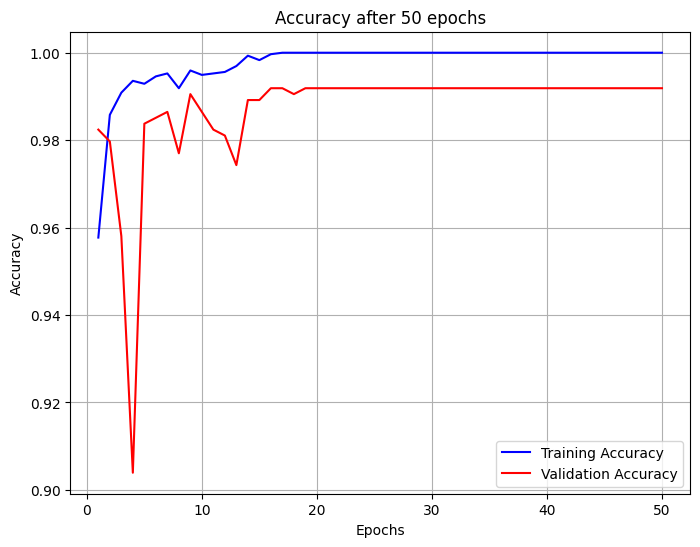

In [20]:
import matplotlib.pyplot as plt

# Extract accuracy and validation accuracy from history
training_accuracy = RESNET50_HISTORY.history['accuracy']
validation_accuracy = RESNET50_HISTORY.history['val_accuracy']

# Plot training and validation accuracy
epochs = range(1, len(training_accuracy) + 1)
plt.figure(figsize=(8, 6))
plt.plot(epochs, training_accuracy, 'b-', label='Training Accuracy')
plt.plot(epochs, validation_accuracy, 'r-', label='Validation Accuracy')
plt.title('Accuracy after 50 epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
from sklearn.metrics import classification_report
import numpy as np

# Function to evaluate model and compute precision, recall, and F1-score
def evaluate_model(model, dataset):
    y_true = []
    y_pred = []
    
    for images, labels in dataset:
        predictions = model.predict(images)
        y_true.extend(labels.numpy())  # Convert labels to numpy
        y_pred.extend(np.argmax(predictions, axis=1))  # Get predicted class
    
    # Compute classification metrics
    report = classification_report(y_true, y_pred, target_names=['Class 0', 'Class 1'], output_dict=True)
    
    return report

# Evaluate the ResNet50 model
report = evaluate_model(RESNET50_MODEL, DS_VALID)

precision = report['Class 1']['precision']
recall = report['Class 1']['recall']
f1_score = report['Class 1']['f1-score']

print("Classification Report:")
print(report)
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")

C:\Users\saite\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_274']
Received: inputs=Tensor(shape=(32, 256, 256, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


C:\Users\saite\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_274']
Received: inputs=Tensor(shape=(None, 256, 256, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Classification Report:
{'Class 0': {'precision': 0.9926062846580407, 'recall': 0.9962894248608535, 'f1-score': 0.9944444444444445, 'support': 539.0}, 'Class 1': {'precision': 0.98989898989899, 'recall': 0.98, 'f1-score': 0.9849246231155779, 'support': 200.0}, 'accuracy': 0.9918809201623816, 'macro avg': {'precision': 0.9912526372785153, 'recall': 0.9881447124304268, 'f1-score': 0.9896845337800112, 'support': 739.0}, 'weighted avg': {'precision': 0.9918735932482841, 'recall': 0.9918809201623816, 'f1-score': 0.9918680381308135, 'support': 739.0}}
Precision: 0.9899
Recall: 0.9800
F1-Score: 0.9849


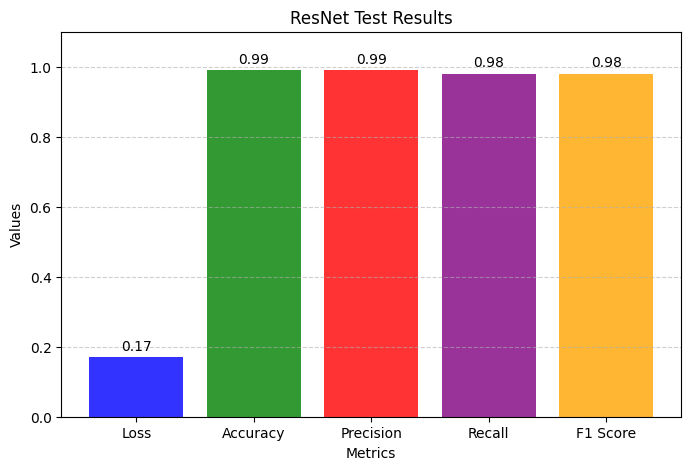

In [7]:
import matplotlib.pyplot as plt

def visualize_lenet_test_results(results):
    """
    Visualize the test results for the LeNet model using a bar chart.
    
    Parameters:
    - results: A list containing values for Loss, Accuracy, Precision, Recall, and F1 Score.
    """
    labels = ['Loss', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
    values = results[:5]  # Ensuring that only the first 5 elements are used for visualization
    # Define bar colors for better visualization
    colors = ['blue', 'green', 'red', 'purple', 'orange']

    # Plotting the bar graph
    plt.figure(figsize=(8, 5))
    plt.bar(labels, values, color=colors, alpha=0.8)
    plt.title('ResNet Test Results')
    plt.xlabel('Metrics')
    plt.ylabel('Values')
    plt.ylim(0, 1.1)  # Assuming metrics range between 0 and 1, adjust as needed
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    # Annotating each bar with its value
    for i, value in enumerate(values):
        plt.text(i, value + 0.02, f"{value:.2f}", ha='center', fontsize=10, color='black')

    plt.show()
test_results = [0.17, 0.99, 0.99, 0.98, 0.98]  
# Example usage
visualize_lenet_test_results(test_results)

In [25]:
from tensorflow.keras.models import load_model
RESNET50_MODEL.save("ResNet.h5")

In [7]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input

# Load and preprocess the image for ResNet50
def preprocess_image(img_path, target_size=(224, 224)):  
    img = image.load_img(img_path, target_size=target_size, color_mode="rgb")  # Load image
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = preprocess_input(img_array)  # Apply ResNet50 preprocessing
    return img_array

# Predict function using ResNet50
def predict_tb(img_path, model, threshold=0.5):
    processed_image = preprocess_image(img_path, target_size=model.input_shape[1:3])  
    prediction = model.predict(processed_image)  # Get prediction

    # Handling both softmax and sigmoid outputs
    if prediction.shape[-1] == 2:  # Softmax case
        predicted_class = np.argmax(prediction)  
        probability = prediction[0][predicted_class]
    else:  # Sigmoid case (Binary classification)
        probability = prediction[0][0]
        predicted_class = int(probability > threshold)

    class_label = "Tuberculosis" if predicted_class == 1 else "Normal"
    return probability, class_label

# Load the trained ResNet model
model = load_model("ResNet.h5")  # Ensure this is your fine-tuned ResNet model

# Example usage
img_path = r"C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Tuberculosis\Tuberculosis-22.png"
probability, label = predict_tb(img_path, model)

print(f"Predicted Probability: {probability:.4f}")
print(f"Prediction: {label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Probability: 1.0000
Prediction: Tuberculosis


In [8]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input

# Load and preprocess the image for ResNet50
def preprocess_image(img_path, target_size=(224, 224)):  
    img = image.load_img(img_path, target_size=target_size, color_mode="rgb")  # Load image
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = preprocess_input(img_array)  # Apply ResNet50 preprocessing
    return img_array

# Predict function using ResNet50
def predict_tb(img_path, model, threshold=0.5):
    processed_image = preprocess_image(img_path, target_size=model.input_shape[1:3])  
    prediction = model.predict(processed_image)  # Get prediction

    # Handling both softmax and sigmoid outputs
    if prediction.shape[-1] == 2:  # Softmax case
        predicted_class = np.argmax(prediction)  
        probability = prediction[0][predicted_class]
    else:  # Sigmoid case (Binary classification)
        probability = prediction[0][0]
        predicted_class = int(probability > threshold)

    class_label = "Tuberculosis" if predicted_class == 1 else "Normal"
    return probability, class_label

# Load the trained ResNet model
model = load_model("ResNet.h5")  # Ensure this is your fine-tuned ResNet model

# Example usage
img_path = r"C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Normal\Normal-4.png"
probability, label = predict_tb(img_path, model)

print(f"Prediction: {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: Normal


In [2]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input

# Load and preprocess the image for ResNet50
def preprocess_image(img_path, target_size=(224, 224)):  
    img = image.load_img(img_path, target_size=target_size, color_mode="rgb")  # Load image
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = preprocess_input(img_array)  # Apply ResNet50 preprocessing
    return img_array

# Predict function using ResNet50
def predict_tb(img_path, model, threshold=0.5):
    processed_image = preprocess_image(img_path, target_size=model.input_shape[1:3])  
    prediction = model.predict(processed_image)  # Get prediction

    # Handling both softmax and sigmoid outputs
    if prediction.shape[-1] == 2:  # Softmax case
        predicted_class = np.argmax(prediction)  
        probability = prediction[0][predicted_class]
    else:  # Sigmoid case (Binary classification)
        probability = prediction[0][0]
        predicted_class = int(probability > threshold)

    class_label = "Tuberculosis" if predicted_class == 1 else "Normal"
    return probability, class_label

# Load the trained ResNet model
model = load_model("ResNet.h5")  # Ensure this is your fine-tuned ResNet model

# Example usage
img_path = r"C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Tuberculosis\Tuberculosis-92.png"
probability, label = predict_tb(img_path, model)

print(f"Prediction: {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: Tuberculosis


In [6]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input

# Load and preprocess the image for ResNet50
def preprocess_image(img_path, target_size=(224, 224)):  
    img = image.load_img(img_path, target_size=target_size, color_mode="rgb")  # Load image
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = preprocess_input(img_array)  # Apply ResNet50 preprocessing
    return img_array

# Predict function using ResNet50
def predict_tb(img_path, model, threshold=0.5):
    processed_image = preprocess_image(img_path, target_size=model.input_shape[1:3])  
    prediction = model.predict(processed_image)  # Get prediction

    # Handling both softmax and sigmoid outputs
    if prediction.shape[-1] == 2:  # Softmax case
        predicted_class = np.argmax(prediction)  
        probability = prediction[0][predicted_class]
    else:  # Sigmoid case (Binary classification)
        probability = prediction[0][0]
        predicted_class = int(probability > threshold)

    class_label = "Tuberculosis" if predicted_class == 1 else "Normal"
    return probability, class_label

# Load the trained ResNet model
model = load_model("ResNet.h5")  # Ensure this is your fine-tuned ResNet model

# Example usage
img_path = r"C:\MAJOR\Dataset\jfmdp-4-073-001.gif"
probability, label = predict_tb(img_path, model)

print(f"Prediction: {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: Tuberculosis


In [10]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input

# Load and preprocess the image for ResNet50
def preprocess_image(img_path, target_size=(224, 224)):  
    img = image.load_img(img_path, target_size=target_size, color_mode="rgb")  # Load image
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = preprocess_input(img_array)  # Apply ResNet50 preprocessing
    return img_array

# Predict function using ResNet50
def predict_tb(img_path, model, threshold=0.5):
    processed_image = preprocess_image(img_path, target_size=model.input_shape[1:3])  
    prediction = model.predict(processed_image)  # Get prediction

    # Handling both softmax and sigmoid outputs
    if prediction.shape[-1] == 2:  # Softmax case
        predicted_class = np.argmax(prediction)  
        probability = prediction[0][predicted_class]
    else:  # Sigmoid case (Binary classification)
        probability = prediction[0][0]
        predicted_class = int(probability > threshold)

    class_label = "Tuberculosis" if predicted_class == 1 else "Normal"
    return probability, class_label

# Load the trained ResNet model
model = load_model("ResNet.h5")  # Ensure this is your fine-tuned ResNet model

# Example usage
img_path = r"C:\MAJOR\Dataset\76052f7902246ff862f52f5d3cd9cd_gallery.jpg"
probability, label = predict_tb(img_path, model)

print(f"Prediction: {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: Normal


In [5]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input

# Load and preprocess the image for ResNet50
def preprocess_image(img_path, target_size=(224, 224)):  
    img = image.load_img(img_path, target_size=target_size, color_mode="rgb")  # Load image
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = preprocess_input(img_array)  # Apply ResNet50 preprocessing
    return img_array

# Predict function using ResNet50
def predict_tb(img_path, model, threshold=0.5):
    processed_image = preprocess_image(img_path, target_size=model.input_shape[1:3])  
    prediction = model.predict(processed_image)  # Get prediction

    # Handling both softmax and sigmoid outputs
    if prediction.shape[-1] == 2:  # Softmax case
        predicted_class = np.argmax(prediction)  
        probability = prediction[0][predicted_class]
    else:  # Sigmoid case (Binary classification)
        probability = prediction[0][0]
        predicted_class = int(probability > threshold)

    class_label = "Tuberculosis" if predicted_class == 1 else "Normal"
    return probability, class_label

# Load the trained ResNet model
model = load_model("ResNet.h5")  # Ensure this is your fine-tuned ResNet model

# Example usage
img_path = r"C:\MAJOR\Dataset\Chest-X-ray-of-normal-lung-without-TB-infection-Dark-areas-show-no-TB-infection.png"
probability, label = predict_tb(img_path, model)

print(f"Prediction: {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: Normal


In [5]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input

# Load and preprocess the image for ResNet50
def preprocess_image(img_path, target_size=(224, 224)):  
    img = image.load_img(img_path, target_size=target_size, color_mode="rgb")  # Load image
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = preprocess_input(img_array)  # Apply ResNet50 preprocessing
    return img_array

# Predict function using ResNet50
def predict_tb(img_path, model, threshold=0.5):
    processed_image = preprocess_image(img_path, target_size=model.input_shape[1:3])  
    prediction = model.predict(processed_image)  # Get prediction

    # Handling both softmax and sigmoid outputs
    if prediction.shape[-1] == 2:  # Softmax case
        predicted_class = np.argmax(prediction)  
        probability = prediction[0][predicted_class]
    else:  # Sigmoid case (Binary classification)
        probability = prediction[0][0]
        predicted_class = int(probability > threshold)

    class_label = "Tuberculosis" if predicted_class == 1 else "Normal"
    return probability, class_label

# Load the trained ResNet model
model = load_model("ResNet.h5")  # Ensure this is your fine-tuned ResNet model

# Example usage
img_path = r"C:\MAJOR\Dataset\images.jpeg"
probability, label = predict_tb(img_path, model)

print(f"Prediction: {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: Tuberculosis
